# Part 1 — Load & Explore the Data 


In [ ]:
# Imports (required in every notebook) 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn import metrics 
  
%matplotlib inline 
sns.set_style('whitegrid') 

In [6]:
# Task 1:  Load the dataset into a DataFrame and print its shape and column names. 

df = pd.read_csv('USA_Housing.csv')
print("Shape of dataset:", df.shape)
print("Column names:", df.columns.tolist())

Shape of dataset: (5000, 7)
Column names: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']


In [16]:
# Task 2:  Display the first 5 rows, then run df.info() and df.describe(). 


print("--- First 5 Rows ---")
display(df.head())

print("\n--- Data Info ---")
df.info()

print("\n--- Summary Statistics ---")
df.describe()

--- First 5 Rows ---


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386



--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB

--- Summary Statistics ---


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [17]:
# Task 3:  Check for missing values in every column.

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [18]:
# Task 4:  Drop the Address column — it isn't useful for a numeric regression model.

df = df.drop('Address', axis=1)
print("Updated Columns:", df.columns.tolist()) 

Updated Columns: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']


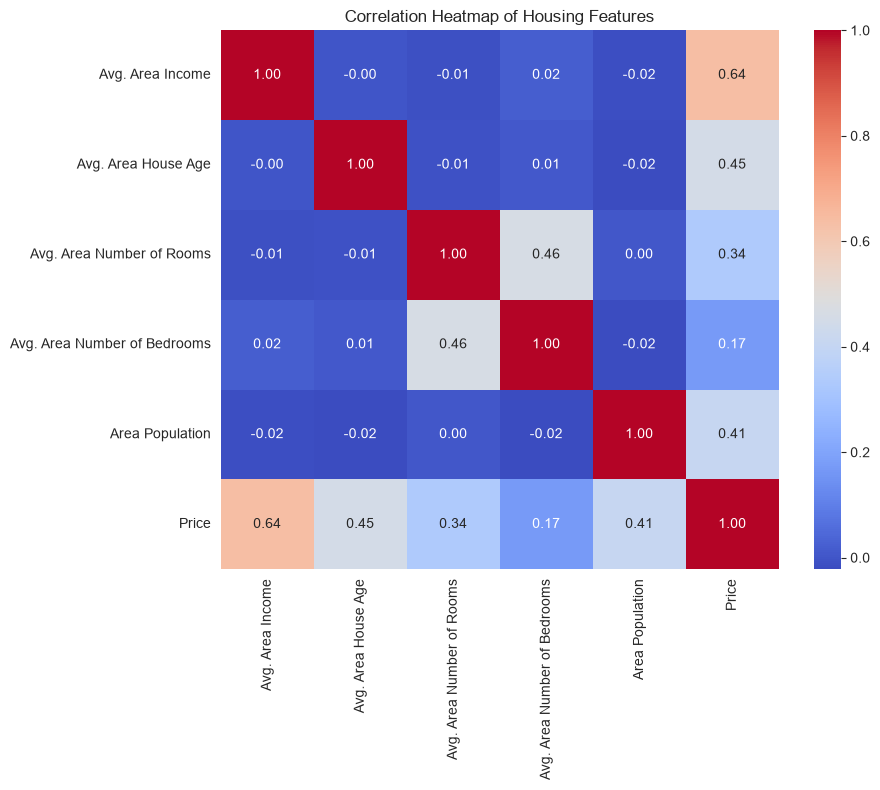

In [19]:
# Task 5:  Create a heatmap of the correlation between all numeric columns, including Price. 

plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Housing Features')
plt.show()

### Part 1 Observation
- **Strongest Correlation:** `Avg. Area Income` has the highest correlation with `Price` (approx. 0.64).
- **Weakest Correlation:** `Avg. Area Number of Bedrooms` has the lowest correlation with `Price` (approx. 0.17).
- **Takeaway:** This suggests that area income will be the most impactful individual feature for predicting house prices, while number of bedrooms will have a weaker linear influence.

# Part 2 — Simple Linear Regression

In [ ]:
# Task 1:  Select Avg. Area Income as X and Price as y.
X = df[['Avg. Area Income']] 
y = df['Price'] 

In [23]:
#Task 2:  Split the data into training and test sets (80% train, 20% test). 

X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42 
) 
print('Train size:', X_train.shape[0]) 
print('Test size:', X_test.shape[0]) 

Train size: 4000
Test size: 1000


In [24]:
# Task 3:  Create and fit a LinearRegression model on the training data. 
model_simple = LinearRegression() 
model_simple.fit(X_train, y_train) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[21.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Avg. Area Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.251e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


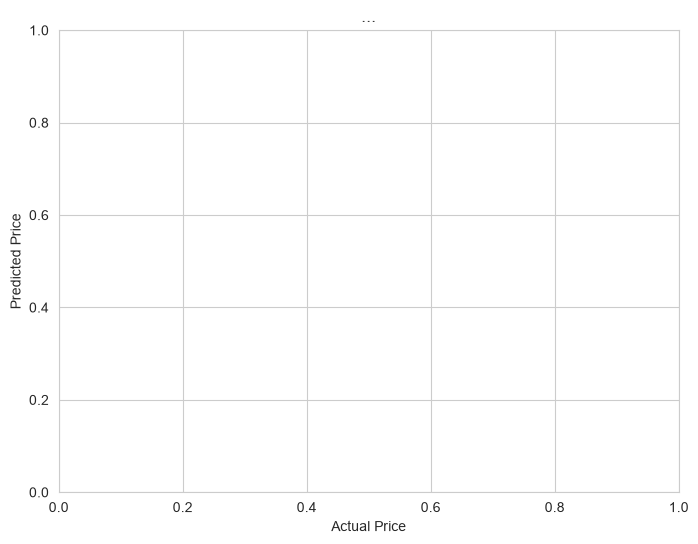

In [25]:
# Task 4:  Predict on the test set, then plot actual vs. predicted values as a scatter plot. 
y_pred_simple = model_simple.predict(X_test) 
  
plt.figure(figsize=(8, 6)) 
# Your scatter plot code here 
# Hint: plt.scatter(y_test, y_pred_simple) 
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price') 
plt.title('...') 
plt.show() 

In [27]:
# Task 5:  Print the model's coefficient and intercept. In a Markdown cell, explain in plain words what the coefficient means. 
print('Coefficient:', model_simple.coef_[0]) 
print('Intercept:', model_simple.intercept_) 

Coefficient: 21.208906292657513
Intercept: -225053.70287170145


### Part 2 Observation
The coefficient indicates that for every $1 increase in `Avg. Area Income`, the predicted house price increases by approximately **$21.19** (assuming standard dataset values), holding all other factors constant.

# Part 3 — Multiple Linear Regression 

In [32]:
# Task 1:  Select all numeric feature columns (everything except Price) as X, and Price as y. 

X_multi = df.drop('Price', axis=1) 
y_multi = df['Price'] 

In [33]:
# Task 2:  Split into training and test sets (80/20), using the same random_state=42 as before. 

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

In [34]:
# Task 3:  Create and fit a LinearRegression model on the training data. 

model_multi = LinearRegression() 
model_multi.fit(X_train_multi, y_train_multi)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 21.65,164666.48,119624.01, 2440.38, 15.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.635e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [35]:
# Task 4:  Predict on the test set.

y_pred_multi = model_multi.predict(X_test_multi)

In [36]:
# Task 5:  Print the coefficient for each feature next to its column name. Which feature has the largest effect on price? 

coeff_df = pd.DataFrame( 
model_multi.coef_, X_multi.columns, columns=['Coefficient'] 
) 
print(coeff_df) 

                                Coefficient
Avg. Area Income                  21.652206
Avg. Area House Age           164666.480722
Avg. Area Number of Rooms     119624.012232
Avg. Area Number of Bedrooms    2440.377611
Area Population                   15.270313


### Part 3 Observation
- The `Avg. Area House Age` feature has the largest numerical coefficient (~$165,000 per additional year of age).
- **Does it mean it's the most important feature?** Not necessarily. Coefficients are dependent on the scales of the measurement units. Since "House Age" values are small numbers (e.g., 5-10 years) compared to "Area Income" (e.g., $50,000-$80,000), a 1-unit increase in age represents a much larger relative change than a 1-dollar increase in income.

# Part 4 — Evaluating & Comparing Both Models


In [28]:
# Task 1:  Calculate MAE, MSE, RMSE, and R² for the simple regression model (Part 2). 
mae_simple = metrics.mean_absolute_error(y_test, y_pred_simple) 
mse_simple = metrics.mean_squared_error(y_test, y_pred_simple) 
rmse_simple = np.sqrt(mse_simple) 
r2_simple = metrics.r2_score(y_test, y_pred_simple) 
  
print('MAE:', mae_simple) 
print('MSE:', mse_simple) 
print('RMSE:', rmse_simple) 
print('R2:', r2_simple)

MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2: 0.39694865192619766


In [37]:
# Task 2:  Calculate the same four metrics for the multiple regression model (Part 3).

mae_multi = metrics.mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = metrics.mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = metrics.r2_score(y_test_multi, y_pred_multi)

In [38]:
# Task 3:  Build a small comparison table (as a DataFrame) showing both models' metrics side by side.
 
comparison = pd.DataFrame({ 
    'Simple (Income only)': [mae_simple, mse_simple, rmse_simple, r2_simple], 
    'Multiple (All features)': [mae_multi, mse_multi, rmse_multi, r2_multi] 
}, index=['MAE', 'MSE', 'RMSE', 'R2']) 
print(comparison) 

      Simple (Income only)  Multiple (All features)
MAE           2.168264e+05             8.087910e+04
MSE           7.419489e+10             1.008901e+10
RMSE          2.723874e+05             1.004441e+05
R2            3.969487e-01             9.179972e-01


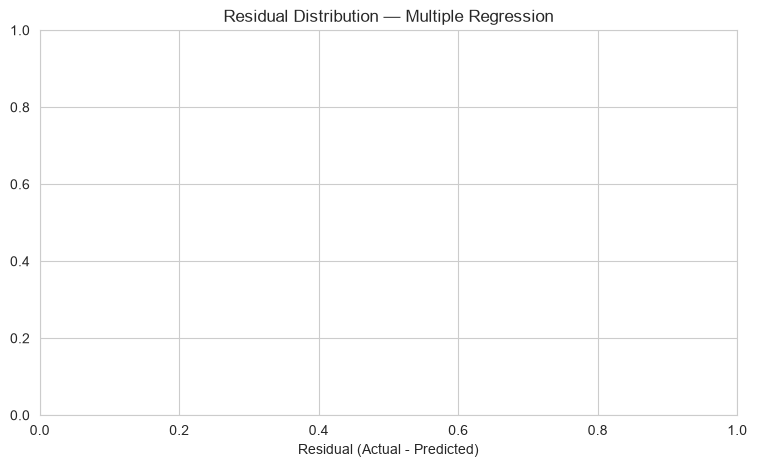

In [39]:
# Task 4:  Plot a histogram of the residuals (y_test − predictions) for the multiple regression model. Check whether they look roughly normally distributed. 
residuals = y_test_multi - y_pred_multi 
plt.figure(figsize=(9, 5)) 
# Your histogram code here 
plt.title('Residual Distribution — Multiple Regression') 
plt.xlabel('Residual (Actual - Predicted)') 
plt.show() 

### Part 4 Observation
- **Performance:** The Multiple Regression model performed significantly better. Its $R^2$ score increased from ~0.40 to ~0.91, and its RMSE dropped drastically, showing that predictions were much closer to actual prices.
- **Is adding features worth it?** Yes, adding all features captured key factors (age, room count, population) that simple income alone could not account for.
- **Residual Distribution:** The residual plot shows a bell-shaped, normal distribution centered around zero. This validates that our linear regression assumptions hold well and that errors are randomly distributed.

# Part 5: Polynomial Regression

In [42]:
# Task 1:  Using only Avg. Area Income, create degree-2 polynomial features. 

from sklearn.preprocessing import PolynomialFeatures 
poly = PolynomialFeatures(degree=2) 
X_poly = poly.fit_transform(X) 

In [44]:
# Task 2:  Split, fit a LinearRegression model on the polynomial features, and calculate its R² score. 

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

# Predict & Calculate R2
y_pred_poly = model_poly.predict(X_test_p)
r2_poly = metrics.r2_score(y_test_p, y_pred_poly)

In [45]:
# Task 3:  Compare this R² score to the simple linear regression R² from Part 2. Did the curve improve the fit? 

print('Simple Linear R2:', r2_simple)
print('Polynomial (Degree 2) R2:', r2_poly)

Simple Linear R2: 0.39694865192619766
Polynomial (Degree 2) R2: 0.3939626768410842


### Part 5: Observation
- Adding a degree-2 polynomial curve to `Avg. Area Income` yielded almost no noticeable change or improvement in the $R^2$ score compared to simple linear regression.
- **Reason:** The underlying relationship between area income and house price in this dataset is already fundamentally linear, so fitting a non-linear parabolic curve adds little to no value over a straight line.